In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, patheffects
from matplotlib.colors import Normalize, ListedColormap
from scipy.interpolate import griddata

In [2]:
# Load input files
# See pipeline to see how these were generated

# NMF file for 3D info
nmf = pd.read_csv('data/TP53_nmfinfo_final.csv')

# Log odds file with per residue scores, here for PF-4800567
logodds = pd.read_csv('data/TP53_pf-4800567_logodds.csv')
logodds["mlp"] = logodds["mlp"].astype(int)
logodds["cluster_id"] = logodds["cluster_id"].astype(int)

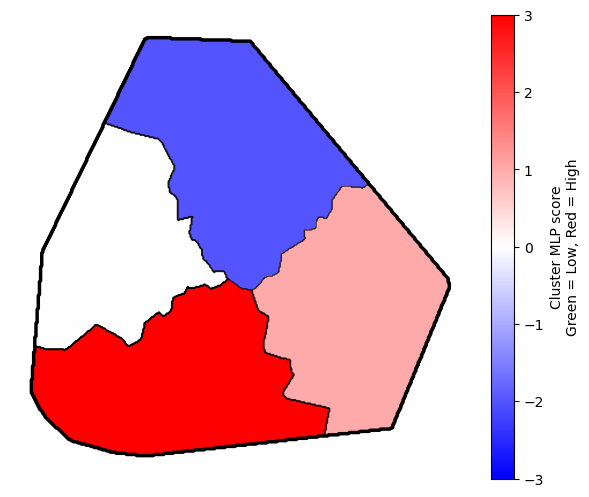

In [3]:
# Grid setup
xmn, xmx = nmf["x_axis"].min(), nmf["x_axis"].max()
ymn, ymx = nmf["y_axis"].min(), nmf["y_axis"].max()

pad_x = 0.05 * (xmx - xmn)
pad_y = 0.05 * (ymx - ymn)

xmn_pad, xmx_pad = xmn - pad_x, xmx + pad_x
ymn_pad, ymx_pad = ymn - pad_y, ymx + pad_y

nx, ny = 400, 400
xi = np.linspace(xmn_pad, xmx_pad, nx)
yi = np.linspace(ymn_pad, ymx_pad, ny)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate altitude to define protein boundary
Zi_alt = griddata(
    (nmf["x_axis"], nmf["y_axis"]),
    nmf["altitude"],
    (Xi, Yi),
    method="linear"
)

outer_mask = np.isnan(Zi_alt) | (Zi_alt <= np.nanmin(Zi_alt) + 1e-6)
inside_mask = (~outer_mask).astype(float)

# Interpolate cluster grid
Zi_cluster = griddata(
    (nmf["x_axis"], nmf["y_axis"]),
    nmf["clust"],
    (Xi, Yi),
    method="nearest"
)

Zi_cluster_masked = np.ma.array(Zi_cluster, mask=outer_mask)

# Map cluster_id -> log-odds / MLP score
cluster_scores = logodds.set_index("cluster_id")["mlp"]

# Fill each cluster with its log-odds score
Zi_score_cluster = np.full_like(Zi_cluster, np.nan, dtype=float)

for clust, val in cluster_scores.items():
    Zi_score_cluster[np.isclose(Zi_cluster, clust)] = val

Zi_score_masked = np.ma.array(Zi_score_cluster, mask=outer_mask)

# Color scaling
vi_max = np.nanmax(np.abs(cluster_scores.values))
norm = Normalize(vmin=-vi_max, vmax=vi_max)
cmap = cm.bwr

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axis("off")

im = ax.imshow(
    Zi_score_masked,
    origin="lower",
    extent=(xmn_pad, xmx_pad, ymn_pad, ymx_pad),
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    zorder=0
)

# Cluster outlines
ax.contour(
    Xi, Yi, Zi_cluster_masked,
    levels=np.unique(nmf["clust"]),
    colors="black",
    linewidths=1.0,
    alpha=0.8,
    zorder=2
)

# Outer border
ax.contour(
    Xi, Yi, inside_mask,
    levels=[0.5],
    colors="black",
    linewidths=2.5,
    zorder=3
)

cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Cluster MLP score\nGreen = Low, Red = High")

ax.set_xlim(xmn_pad, xmx_pad)
ax.set_ylim(ymn_pad, ymx_pad)

plt.tight_layout()
plt.show()